In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install pyarrow

In [3]:
all_data = pd.read_feather(r'D:\sales data analysis\sales_data.ftr')

In [4]:
all_data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [5]:
all_data = all_data.dropna(how = "all")

In [6]:
all_data.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [7]:
all_data = all_data.drop_duplicates()

In [8]:
all_data[all_data.duplicated()]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [9]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [10]:
all_data['Order Date']

0         04/19/19 08:46
2         04/07/19 22:30
3         04/12/19 14:38
4         04/12/19 14:38
5         04/30/19 09:27
               ...      
186845    09/17/19 20:56
186846    09/01/19 16:00
186847    09/23/19 07:39
186848    09/19/19 17:30
186849    09/30/19 00:18
Name: Order Date, Length: 185687, dtype: object

In [11]:
all_data['Order Date'].unique()

array(['04/19/19 08:46', '04/07/19 22:30', '04/12/19 14:38', ...,
       '09/23/19 07:39', '09/19/19 17:30', '09/30/19 00:18'], dtype=object)

In [12]:
def return_month(x):
    return x.split('/')[0]
    

In [13]:
all_data['Month'] = all_data['Order Date'].apply(return_month)

In [14]:
all_data['Month'].astype(int)

ValueError: invalid literal for int() with base 10: 'Order Date'

In [15]:
all_data['Month'].unique()

array(['04', '05', 'Order Date', '08', '09', '12', '01', '02', '03', '07',
       '06', '11', '10'], dtype=object)

In [16]:
filter1 = all_data['Month'] == 'Order Date'

In [17]:
all_data = all_data[~filter1]

In [18]:
all_data['Month'].astype(int)

0         4
2         4
3         4
4         4
5         4
         ..
186845    9
186846    9
186847    9
186848    9
186849    9
Name: Month, Length: 185686, dtype: int32

In [19]:
all_data['Quantity Ordered'] = all_data['Quantity Ordered'].astype(int)

In [20]:
all_data['Price Each'] = all_data['Price Each'].astype(float)

In [21]:
all_data['sales'] = all_data['Quantity Ordered']*all_data['Price Each']

In [22]:
all_data['sales']

0          23.90
2          99.99
3         600.00
4          11.99
5          11.99
           ...  
186845      8.97
186846    700.00
186847    700.00
186848    379.99
186849     11.95
Name: sales, Length: 185686, dtype: float64

<Axes: xlabel='Month'>

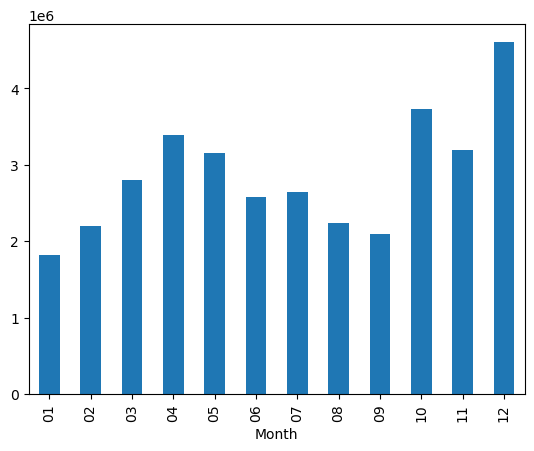

In [23]:
all_data.groupby(['Month'])['sales'].sum().plot(kind = 'bar')

In [24]:
all_data.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",04,99.99


In [25]:
all_data['Purchase Address']

0                    917 1st St, Dallas, TX 75001
2               682 Chestnut St, Boston, MA 02215
3            669 Spruce St, Los Angeles, CA 90001
4            669 Spruce St, Los Angeles, CA 90001
5               333 8th St, Los Angeles, CA 90001
                           ...                   
186845     840 Highland St, Los Angeles, CA 90001
186846    216 Dogwood St, San Francisco, CA 94016
186847       220 12th St, San Francisco, CA 94016
186848     511 Forest St, San Francisco, CA 94016
186849     250 Meadow St, San Francisco, CA 94016
Name: Purchase Address, Length: 185686, dtype: object

In [26]:
all_data['city'] = all_data['Purchase Address'].str.split(',').str.get(1)

In [27]:
all_data['city']

0                 Dallas
2                 Boston
3            Los Angeles
4            Los Angeles
5            Los Angeles
               ...      
186845       Los Angeles
186846     San Francisco
186847     San Francisco
186848     San Francisco
186849     San Francisco
Name: city, Length: 185686, dtype: object

C:\Users\DELL\AppData\Local\Temp\ipykernel_14848\3519874178.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(all_data['city']).plot(kind='pie' , autopct = '%1.0f%%')


<Axes: ylabel='count'>

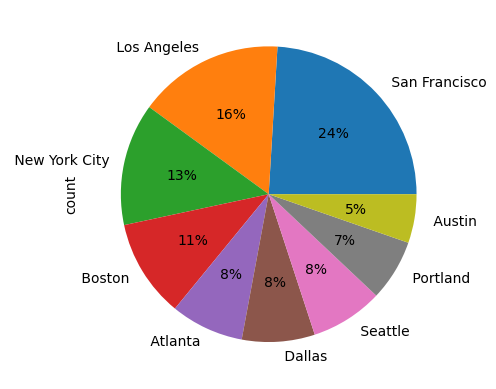

In [28]:
pd.value_counts(all_data['city']).plot(kind='pie' , autopct = '%1.0f%%')

In [29]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Month', 'sales', 'city'],
      dtype='object')

In [30]:
count_df = all_data.groupby(['Product']).agg({'Quantity Ordered':'sum' , 'Price Each':'mean'})

In [79]:
count_df = count_df.reset_index()

In [80]:
count_df

,index,Product,Quantity Ordered,Price Each
0,0,20in Monitor,4126,109.99
1,1,27in 4K Gaming Monitor,6239,389.99
2,2,27in FHD Monitor,7541,149.99
3,3,34in Ultrawide Monitor,6192,379.99
4,4,AA Batteries (4-pack),27615,3.84
5,5,AAA Batteries (4-pack),30986,2.99
6,6,Apple Airpods Headphones,15637,150.00
7,7,Bose SoundSport Headphones,13430,99.99
8,8,Flatscreen TV,4813,300.00
9,9,Google Phone,5529,600.00


In [32]:
products = count_df['Product'].values

C:\Users\DELL\AppData\Local\Temp\ipykernel_14848\2079447910.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axi1.set_xticklabels(products , rotation = 'vertical', fontsize = 8)


Text(0, 0.5, 'avg price of product')

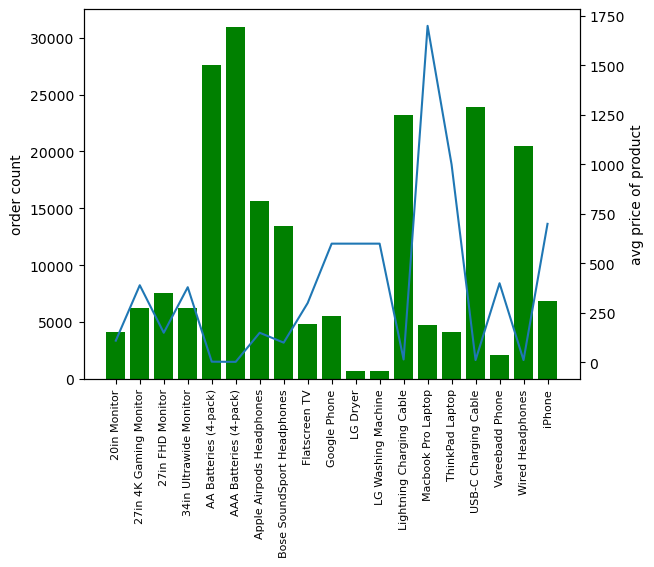

In [33]:
fig , axi1 = plt.subplots()
axi2 = axi1.twinx()
axi1.bar(count_df['Product'] , count_df['Quantity Ordered'] , color = 'g')
axi2.plot(count_df['Product'] , count_df['Price Each'])
axi1.set_xticklabels(products , rotation = 'vertical', fontsize = 8)
axi1.set_ylabel('order count')
axi2.set_ylabel('avg price of product')


In [38]:
all_data['Product'].value_counts()[0:5].index

Index(['USB-C Charging Cable', 'Lightning Charging Cable',
       'AAA Batteries (4-pack)', 'AA Batteries (4-pack)', 'Wired Headphones'],
      dtype='object', name='Product')

In [39]:
most_sold_products = all_data['Product'].value_counts()[0:5].index

In [42]:
most_sold_products_df = all_data[all_data['Product'].isin(most_sold_products)]

In [43]:
most_sold_products_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04,23.90,Dallas
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04,11.99,Los Angeles
6,176562,USB-C Charging Cable,1,11.95,04/29/19 13:03,"381 Wilson St, San Francisco, CA 94016",04,11.95,San Francisco
8,176564,USB-C Charging Cable,1,11.95,04/12/19 10:58,"790 Ridge St, Atlanta, GA 30301",04,11.95,Atlanta
...,...,...,...,...,...,...,...,...,...
186840,259349,AAA Batteries (4-pack),1,2.99,09/01/19 22:14,"911 River St, Dallas, TX 75001",09,2.99,Dallas
186842,259350,USB-C Charging Cable,1,11.95,09/30/19 13:49,"519 Maple St, San Francisco, CA 94016",09,11.95,San Francisco
186844,259352,USB-C Charging Cable,1,11.95,09/07/19 15:49,"976 Forest St, San Francisco, CA 94016",09,11.95,San Francisco
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001",09,8.97,Los Angeles


In [50]:
pivot = most_sold_products_df.groupby(['Month' , 'Product']).size().unstack()

<Axes: xlabel='Month'>

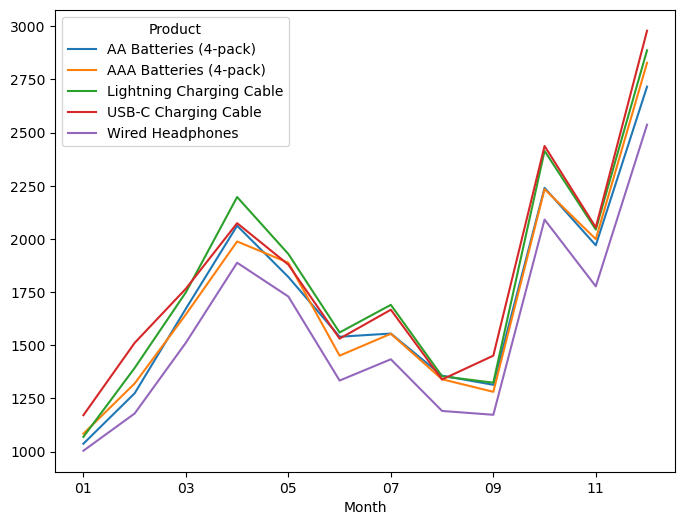

In [51]:
pivot.plot(figsize = (8,6))

In [57]:
df_duplicated = all_data[all_data['Order ID'].duplicated(keep = False)]

In [67]:
df_dup = df_duplicated.groupby(['Order ID'])['Product'].apply(lambda x :','.join(x)).reset_index().rename(columns = {'Product' : 'grouped_products'})

In [69]:
df_dup_products = df_duplicated.merge(df_dup , how = 'left', on = 'Order ID' )

In [74]:
no_dup_df = df_dup_products.drop_duplicates(subset = ['Order ID'])

<Axes: ylabel='count'>

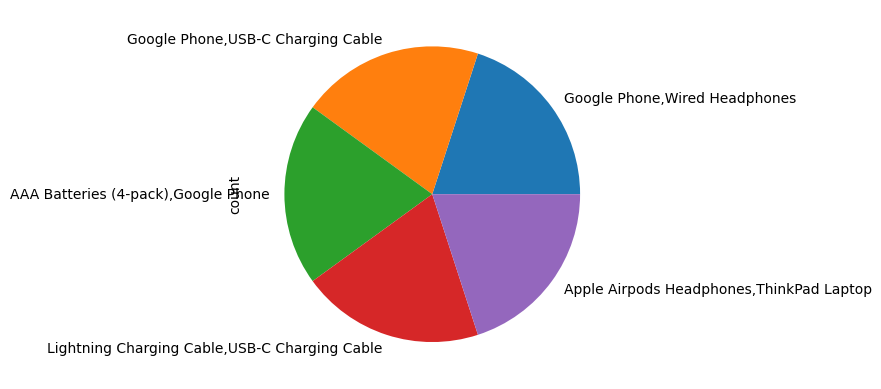

In [78]:
no_dup_df['grouped_products'][0:5].value_counts().plot.pie()